# 06e. 최종 모델 다차원 평가 및 시각화 (Model Evaluation)

## 개요
- **목적**: Optuna 하이퍼파라미터 최적화(`06d`)를 통해 완성된 최적 앙상블 모델을 로드하여 다차원 평가를 진행합니다.
- **평가 대상**: `val_tune.parquet` (모델 탐색 및 튜닝용 검증 데이터)
- **평가 원칙**:
  1. **개체(디스크) 단위 롤링 평가**: notebooks2 표준 스탠다드에 의거하여 행 단위 평가는 제외하고, 디스크 개체 단위의 롤링 추론과 30일 리드타임 기준으로 평가합니다.
  2. **독립성 유지**: 테스트셋 오염 방지를 위해 최종 테스트셋 평가는 배제하고 오직 학습 검증용 `val_tune`로만 평가 및 시각화를 수행합니다.

In [10]:
import os
import sys
from pathlib import Path

# 코드 변경 자동 반영 (autoreload)
%load_ext autoreload
%autoreload 2

# ── 프로젝트 루트 경로 추가 ───────────────────────
ROOT = Path(os.getcwd()).parent.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from config import train_config
from config import threshold_config
from src.eval_core import (
    load_saved_ensemble,
    EntityLevelEvaluator
)

print(f"✅ 프로젝트 루트 설정 완료: {ROOT}")
print(f"✅ eval_core 및 설정 라이브러리 로드 완료")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ 프로젝트 루트 설정 완료: c:\Workspace\06_ML_projdect\26_1_COIN
✅ eval_core 및 설정 라이브러리 로드 완료


## 1. 저장된 최적 앙상블 모델 로드

`models2/06d_optuna_tuning/seed_42` 폴더 내에 저장된 서브셋 모델들과 피처 명세를 로드합니다.

In [11]:
print(f"🔄 모델 디렉토리: {threshold_config.MODEL_SAVE_DIR}")

# threshold 파일이 있는지 확인
threshold_file = Path(threshold_config.MODEL_SAVE_DIR) / "best_threshold.json"
has_threshold = threshold_file.is_file()

meta = load_saved_ensemble(threshold_config, require_threshold=has_threshold)

ensemble = meta["ensemble"]
FEATURE_COLS = meta["feature_cols"]
BEST_T = meta["threshold"] if has_threshold else 0.3  # 기본값 백업

print(f"\n✅ 로드된 앙상블 서브셋 수: {len(ensemble.models)}개")
print(f"✅ 사용 피처 수: {len(FEATURE_COLS)}개")
if has_threshold:
    print(f"✅ 불러온 최적 임계값 (best_threshold.json): {BEST_T:.6f}")

🔄 모델 디렉토리: C:\Workspace\06_ML_projdect\26_1_COIN\results\models\seed_42
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\results\models\seed_42
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\results\models\seed_42\feature_cols.json (17 features)
  threshold_path: C:\Workspace\06_ML_projdect\26_1_COIN\results\models\seed_42\best_threshold.json
  threshold: 0.487513
  threshold_source_val_calib: c:\Workspace\06_ML_projdect\26_1_COIN\data2\03_splitting\val_calib.parquet
  model: subset_00.pkl (102,372 bytes)
  model: subset_01.pkl (101,876 bytes)
  model: subset_02.pkl (102,308 bytes)
  model: subset_03.pkl (101,396 bytes)
  model: subset_04.pkl (101,204 bytes)
  joblib 로드 1/5: subset_00.pkl
      → 0.0s
  joblib 로드 2/5: subset_01.pkl
      → 0.0s
  joblib 로드 3/5: subset_02.pkl
      → 0.0s
  joblib 로드 4/5: subset_03.pkl
      → 0.0s
  joblib 로드 5/5: subset_04.pkl
      → 0.0s

✅ 로드된 앙상블 서브셋 수: 5개
✅ 사용 피처 수: 17개
✅ 불러온 최적 임계값 (best_threshold.json): 0.4875

## 2. 검증셋(val_tune) 데이터 로드

튜닝 및 최적화에 사용된 `val_tune_filtered.parquet` 데이터를 로드합니다.

In [12]:
val_tune_path = ROOT / "data2" / "06_hyperparameter_tuning" / "val_tune.parquet"

print(f"🔄 val_tune 로드 중: {val_tune_path.name}")
df_val = pd.read_parquet(val_tune_path)
print(f"  -> val_tune 크기: {len(df_val):,} rows")

🔄 val_tune 로드 중: fs_validation_filtered.parquet
  -> val_tune 크기: 1,247,377 rows


## 3. 앙상블 모델 소프트보팅(Soft-Voting) 추론

로드된 앙상블 모델을 사용하여 `val_tune`에 대한 예측 확률을 구합니다.

In [13]:
print("🔮 val_tune 데이터 추론...")
y_prob_val = ensemble.predict_proba(df_val, FEATURE_COLS, verbose=True)

from src.eval_core import prepare_disk_level_data
print("\n📊 [val_tune] 개체 단위 데이터 변환 중...")
disks_data, n_failed, n_normal = prepare_disk_level_data(
    df_val,
    y_prob_val,
    target_col=threshold_config.TARGET_COL,
    serial_col=threshold_config.SERIAL_COL,
    date_col=threshold_config.DATE_COL
)
print(f"  -> 완료 (총 {len(disks_data):,}개 디스크: 고장 {n_failed}개, 정상 {n_normal}개)")

🔮 val_tune 데이터 추론...


KeyError: "['reallocated_pending_ratio', 'total_seeks_14d_mean', 'multi_error_count', 'age_weighted_workload', 'smart_242_raw'] not in index"

🔄 30일 Horizon 기준 디스크 레벨 그리드 서치 수행 중...
  ... 500/1,000 (50.0%) - 0.5s
  ... 1,000/1,000 (100.0%) - 0.8s

🎯 [val_tune] 개체 단위 PR-AUC (Horizon 30일): 0.31301
💾 Plot saved to: results\06e_\plots\06e_disk_far_recall_curve_linear.png


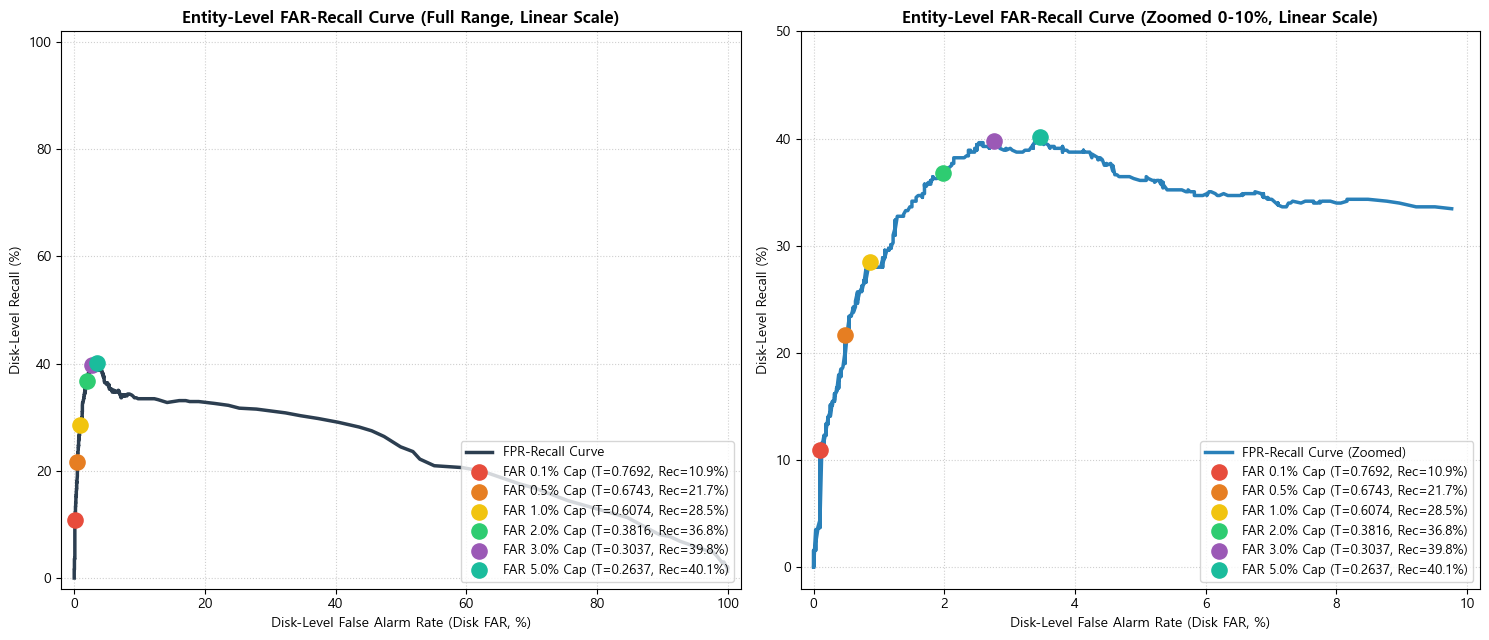

In [ ]:
from src.eval_core import run_disk_level_grid_search
from sklearn.metrics import auc

print("🔄 30일 Horizon 기준 디스크 레벨 그리드 서치 수행 중...")
thresholds_grid = np.linspace(0.001, 0.999, 1000)
df_grid = run_disk_level_grid_search(
    disks_data,
    thresholds_grid,
    [1],
    n_failed,
    n_normal,
    log_dir=None,
    window_size=0,
    horizon=30
)

# 1. 개체 단위 PR-AUC 산출
df_sorted = df_grid.sort_values(by="recall").copy()
df_sorted["precision"] = df_sorted["tps"] / (df_sorted["tps"] + df_sorted["fps"] + 1e-8)
df_sorted["precision"] = df_sorted["precision"].fillna(1.0)
entity_prauc = float(auc(df_sorted["recall"].values, df_sorted["precision"].values))

print(f"\n🎯 [val_tune] 개체 단위 PR-AUC (Horizon 30일): {entity_prauc:.5f}")

# 2. 주요 FAR Cap 기준별 최적 운영점 도출
target_caps = [0.001, 0.005, 0.010, 0.020, 0.030, 0.050]
best_points = []
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#9b59b6", "#1abc9c"]

for cap in target_caps:
    sub = df_grid[df_grid['far'] <= cap]
    if len(sub) > 0:
        # 해당 FAR 이하를 만족하면서 Recall이 가장 높은 지점 선택
        pt = sub.sort_values('recall', ascending=False).iloc[0]
        best_points.append({
            'cap_label': f"{cap*100:.1f}%",
            'threshold': pt['threshold'],
            'far': pt['far'] * 100,
            'recall': pt['recall'] * 100
        })

# 3. 선형 스케일 FAR-Recall 곡선 플로팅 (전체 범위 및 저오탐 범위 분리)
fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# [좌측: 전체 범위 0% ~ 100%]
axes[0].plot(df_grid['far'] * 100, df_grid['recall'] * 100, color="#2c3e50", lw=2.5, label="FPR-Recall Curve")
for idx, pt in enumerate(best_points):
    axes[0].scatter(pt['far'], pt['recall'], color=colors[idx % len(colors)], s=120, zorder=5,
                    label=f"FAR {pt['cap_label']} Cap (T={pt['threshold']:.4f}, Rec={pt['recall']:.1f}%)")
axes[0].set_xlim(-2, 102)
axes[0].set_ylim(-2, 102)
axes[0].set_xlabel("Disk-Level False Alarm Rate (Disk FAR, %)")
axes[0].set_ylabel("Disk-Level Recall (%)")
axes[0].set_title("Entity-Level FAR-Recall Curve (Full Range, Linear Scale)", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=9.5)
axes[0].grid(True, linestyle=":", alpha=0.6)

# [우측: 저오탐 범위 0% ~ 10%]
df_sub = df_grid[df_grid['far'] <= 0.1].sort_values('far')
axes[1].plot(df_sub['far'] * 100, df_sub['recall'] * 100, color="#2980b9", lw=2.5, label="FPR-Recall Curve (Zoomed)")
for idx, pt in enumerate(best_points):
    if pt['far'] <= 10.0:  # 10% 이하인 점들만 표시
        axes[1].scatter(pt['far'], pt['recall'], color=colors[idx % len(colors)], s=120, zorder=5,
                        label=f"FAR {pt['cap_label']} Cap (T={pt['threshold']:.4f}, Rec={pt['recall']:.1f}%)")
axes[1].set_xlim(-0.2, 10.2)
axes[1].set_ylim(-2, 50.0)
axes[1].set_xlabel("Disk-Level False Alarm Rate (Disk FAR, %)")
axes[1].set_ylabel("Disk-Level Recall (%)")
axes[1].set_title("Entity-Level FAR-Recall Curve (Zoomed 0-10%, Linear Scale)", fontweight="bold")
axes[1].legend(loc="lower right", fontsize=9.5)
axes[1].grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

# 이미지 저장
save_dir = Path("results/06e_/plots")
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "06e_disk_far_recall_curve_linear.png", dpi=300)
print(f"💾 Plot saved to: {save_dir / '06e_disk_far_recall_curve_linear.png'}")
plt.show()

## 4. 개체(디스크) 단위 평가 (생애 최초 알람 기준)

동일 시리얼 번호(`serial_number`)를 가진 디스크 개체 단위의 탐지율(Hit Rate), 미탐율(Miss Rate), 오탐율(FA Rate) 및 사전 경보 리드타임을 생애 최초 알람 기준으로 산출합니다.

📐 설정: Min Alarms=1회 (생애 최초 알람 기준)

📊 [val_tune] 개체 단위 평가
  ENTITY-LEVEL ROLLING EVALUATION
  고장 개체 수 : 586
  정상 개체 수 : 7,826

  고장 탐지율 (Hit Rate)  : 0.4078  (239/586)
  미탐율      (Miss Rate) : 0.5922  (347/586)
  오탐율      (FA Rate)   : 0.0063  (49/7826)

  평균 사전 경보 시간 (Lead Time) : 35.0일
  (탐지 못한 개체 제외)


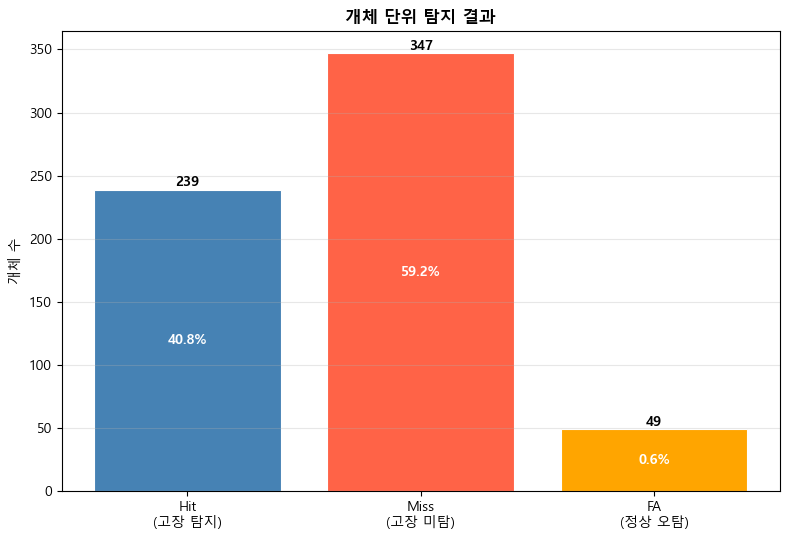

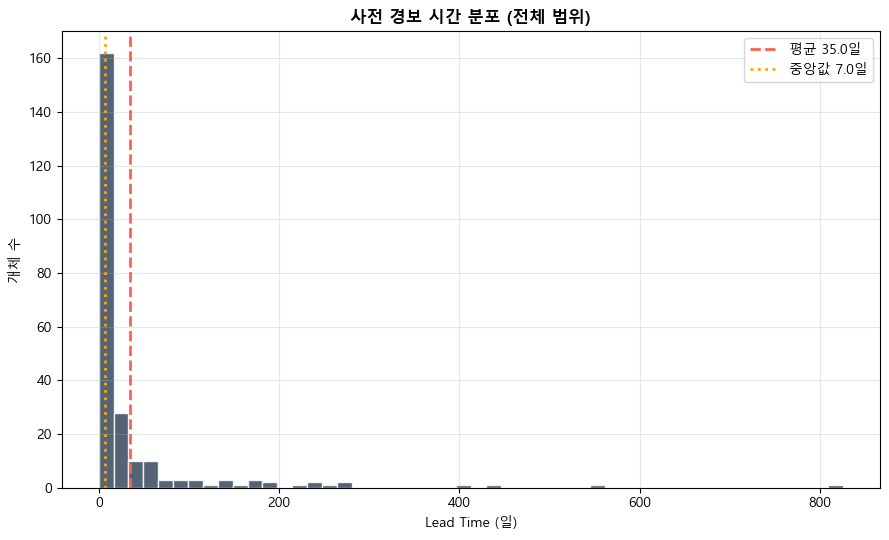

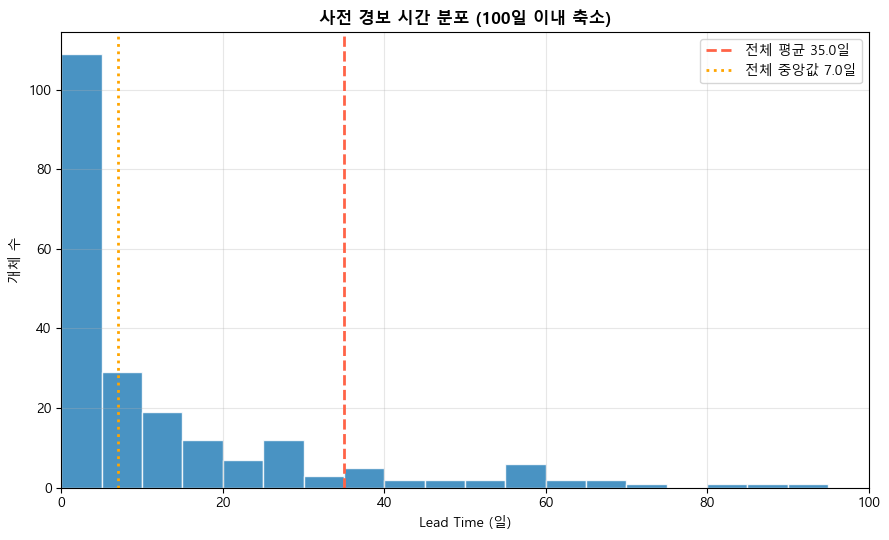

In [ ]:
evaluator = EntityLevelEvaluator(
    serial_col=threshold_config.SERIAL_COL,
    date_col=threshold_config.DATE_COL,
    target_col=threshold_config.TARGET_COL
)

# 알람 최소 횟수 설정 (생애 최초 알람 기준)
min_alarms = 1

print(f"📐 설정: Min Alarms={min_alarms}회 (생애 최초 알람 기준)\n")

print("📊 [val_tune] 개체 단위 평가")
val_ent_res = evaluator.evaluate(df_val, y_prob_val, BEST_T, min_alarms=min_alarms, window_size=None)

# ── 그래프 떼어서 개별 출력 ──
r = val_ent_res
ed = r["entity_df"]
hit_lt = ed[(ed["is_failure"] == 1) & (ed["has_alarm"] == 1)]["lead_time_days"].dropna().values

# 1. 개체 단위 탐지 결과 막대 그래프
fig, ax = plt.subplots(figsize=(8, 5.5))
categories = ["Hit\n(고장 탐지)", "Miss\n(고장 미탐)", "FA\n(정상 오탐)"]
counts = [r["hit_count"], r["miss_count"], r["fa_count"]]
colors = ["steelblue", "tomato", "orange"]
bars = ax.bar(categories, counts, color=colors, edgecolor="white", linewidth=0.8)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{cnt}", ha="center", va="bottom", fontweight="bold")
ax.set_ylabel("개체 수")
ax.set_title("개체 단위 탐지 결과", fontweight="bold", fontsize=12)
ax.grid(axis="y", alpha=0.3)

# 비율 표시
ax.text(0, counts[0]/2, f"{r['hit_rate']*100:.1f}%", ha="center", va="center", color="white", fontweight="bold")
ax.text(1, counts[1]/2 if counts[1] > 0 else 0.5, f"{r['miss_rate']*100:.1f}%", ha="center", va="center", color="white" if counts[1]>0 else "black", fontweight="bold")
ax.text(2, counts[2]/2 if counts[2] > 0 else 0.5, f"{r['fa_rate']*100:.1f}%", ha="center", va="center", color="white" if counts[2]>0 else "black", fontweight="bold")

plt.tight_layout()
plt.show()

if len(hit_lt) > 0:
    # 2. 사전 경보 시간 분포 (전체 범위)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    ax.hist(hit_lt, bins=50, color="#34495e", edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(hit_lt), color="tomato", ls="--", lw=2, label=f"평균 {np.mean(hit_lt):.1f}일")
    ax.axvline(np.median(hit_lt), color="orange", ls=":", lw=2, label=f"중앙값 {np.median(hit_lt):.1f}일")
    ax.set_xlabel("Lead Time (일)")
    ax.set_ylabel("개체 수")
    ax.set_title("사전 경보 시간 분포 (전체 범위)", fontweight="bold", fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. 사전 경보 시간 분포 (100일 이내 축소)
    fig, ax = plt.subplots(figsize=(9, 5.5))
    # 100일 이내의 데이터만 5일 간격으로 그리기
    bins = np.arange(0, 101, 5)
    ax.hist(hit_lt, bins=bins, color="#2980b9", edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(hit_lt), color="tomato", ls="--", lw=2, label=f"전체 평균 {np.mean(hit_lt):.1f}일")
    ax.axvline(np.median(hit_lt), color="orange", ls=":", lw=2, label=f"전체 중앙값 {np.median(hit_lt):.1f}일")
    ax.set_xlim(0, 100)
    ax.set_xlabel("Lead Time (일)")
    ax.set_ylabel("개체 수")
    ax.set_title("사전 경보 시간 분포 (100일 이내 축소)", fontweight="bold", fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("탐지된 고장 개체 없음")

## 5. 리드타임(Lead Time) 구간별 누적 탐지율 및 기술통계 심층 분석

고장 탐지에 성공한 디스크 개체의 리드타임 분포와 누적 탐지 비율을 상세 분석합니다.

📊 val_tune 리드타임(Lead Time) 심층 기술통계
  - 전체 고장 디스크 수 : 586 개
  - 탐지 성공(TP) 디스크 수: 239 개 (Recall: 40.78%)

  [기술통계 요약]
    • 평균(Mean)   : 35.00 일
    • 표준편차(Std): 87.26 일
    • 최소(Min)    : 0.0 일
    • 25% 백분위수 : 1.0 일
    • 중앙값(Med)  : 7.0 일
    • 75% 백분위수 : 25.0 일
    • 최대(Max)    : 825.0 일

📈 구간별 누적 탐지 비율 (Cumulative Detection Rate)
  리드타임 구간 | 탐지 디스크 수 | 탐지 건(TP) 중 비율 | 전체 고장 대비 비율
  ------------------------------------------------------------
   <=  0일 전   |         42 개 |            17.6% |             7.17%
   <=  1일 전   |         67 개 |            28.0% |            11.43%
   <=  3일 전   |         97 개 |            40.6% |            16.55%
   <=  5일 전   |        112 개 |            46.9% |            19.11%
   <=  7일 전   |        124 개 |            51.9% |            21.16%
   <= 10일 전   |        144 개 |            60.3% |            24.57%
   <= 14일 전   |        157 개 |            65.7% |            26.79%
   <= 21일 전   |        172 개 |            72.0% |            29.35%
   <= 3

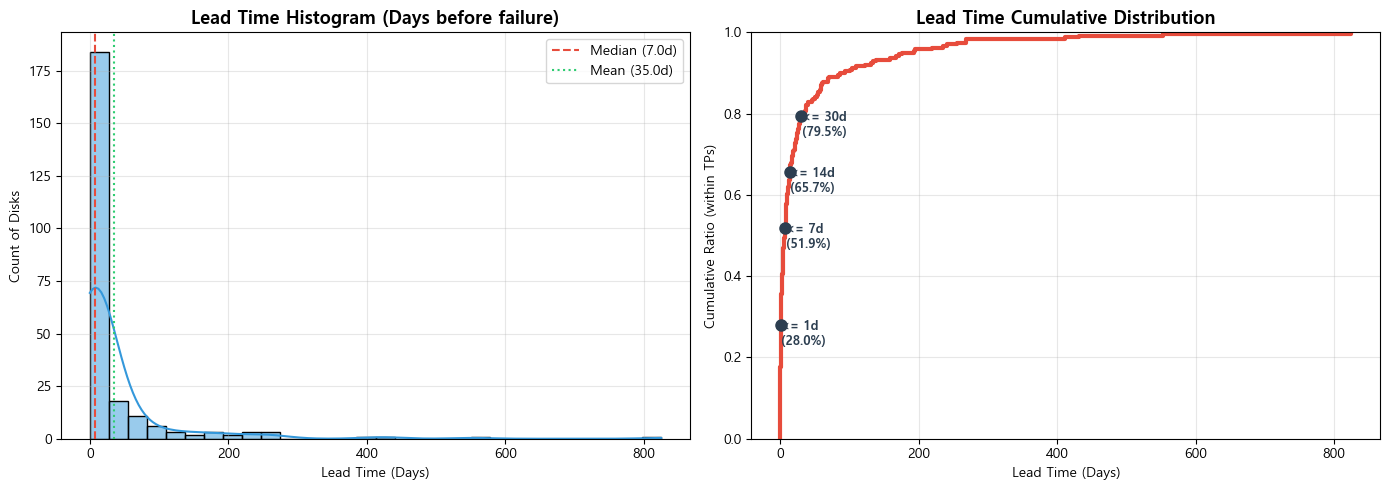

In [ ]:
entity_df = val_ent_res["entity_df"]
fail_entities = entity_df[entity_df["is_failure"] == 1]
detected_failures = fail_entities[fail_entities["has_alarm"] == 1]

total_failed = len(fail_entities)
total_tp = len(detected_failures)
lead_times = detected_failures["lead_time_days"].dropna().values

print(f"============================================================")
print(f"📊 val_tune 리드타임(Lead Time) 심층 기술통계")
print(f"============================================================")
print(f"  - 전체 고장 디스크 수 : {total_failed:,} 개")
print(f"  - 탐지 성공(TP) 디스크 수: {total_tp:,} 개 (Recall: {total_tp/total_failed*100:.2f}%)")
print(f"")
if len(lead_times) > 0:
    print(f"  [기술통계 요약]")
    print(f"    • 평균(Mean)   : {np.mean(lead_times):.2f} 일")
    print(f"    • 표준편차(Std): {np.std(lead_times):.2f} 일")
    print(f"    • 최소(Min)    : {np.min(lead_times)} 일")
    print(f"    • 25% 백분위수 : {np.percentile(lead_times, 25):.1f} 일")
    print(f"    • 중앙값(Med)  : {np.median(lead_times):.1f} 일")
    print(f"    • 75% 백분위수 : {np.percentile(lead_times, 75):.1f} 일")
    print(f"    • 최대(Max)    : {np.max(lead_times)} 일")
print(f"============================================================\n")

print(f"============================================================")
print(f"📈 구간별 누적 탐지 비율 (Cumulative Detection Rate)")
print(f"============================================================")
days_thresholds = [0, 1, 3, 5, 7, 10, 14, 21, 30, 45, 60]

print(f"  리드타임 구간 | 탐지 디스크 수 | 탐지 건(TP) 중 비율 | 전체 고장 대비 비율")
print(f"  ------------------------------------------------------------")
for d_th in days_thresholds:
    detected_within = np.sum(lead_times <= d_th)
    ratio_tp = (detected_within / total_tp * 100) if total_tp > 0 else 0.0
    ratio_all = (detected_within / total_failed * 100) if total_failed > 0 else 0.0
    print(f"   <= {d_th:2d}일 전   | {detected_within:10,} 개 | {ratio_tp:15.1f}% | {ratio_all:16.2f}%")
print(f"============================================================\n")

# 리드타임 분포 시각화 (히스토그램 및 ECDF)
if len(lead_times) > 0:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # 1. 히스토그램
    sns.histplot(lead_times, bins=30, kde=True, color="#3498db", ax=ax1)
    ax1.set_title("Lead Time Histogram (Days before failure)", fontsize=13, fontweight='bold')
    ax1.set_xlabel("Lead Time (Days)")
    ax1.set_ylabel("Count of Disks")
    ax1.axvline(np.median(lead_times), color='#e74c3c', linestyle='--', label=f"Median ({np.median(lead_times):.1f}d)")
    ax1.axvline(np.mean(lead_times), color='#2ecc71', linestyle=':', label=f"Mean ({np.mean(lead_times):.1f}d)")
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 2. ECDF
    sns.ecdfplot(lead_times, color="#e74c3c", lw=3, ax=ax2)
    ax2.set_title("Lead Time Cumulative Distribution", fontsize=13, fontweight='bold')
    ax2.set_xlabel("Lead Time (Days)")
    ax2.set_ylabel("Cumulative Ratio (within TPs)")
    ax2.grid(alpha=0.3)
    
    # 마커 표시
    for d_th in [1, 7, 14, 30]:
        if d_th <= np.max(lead_times):
            y_val = np.sum(lead_times <= d_th) / total_tp
            ax2.plot(d_th, y_val, marker='o', markersize=8, color='#2c3e50')
            ax2.text(d_th+1, y_val-0.05, f"<= {d_th}d\n({y_val*100:.1f}%)", color='#2c3e50', fontweight='bold', fontsize=9)
            
    plt.tight_layout()
    plt.show()

## 6. Operational Acceptance Boundaries (리드타임 구간별 오탐율/탐지율 혼동행렬)

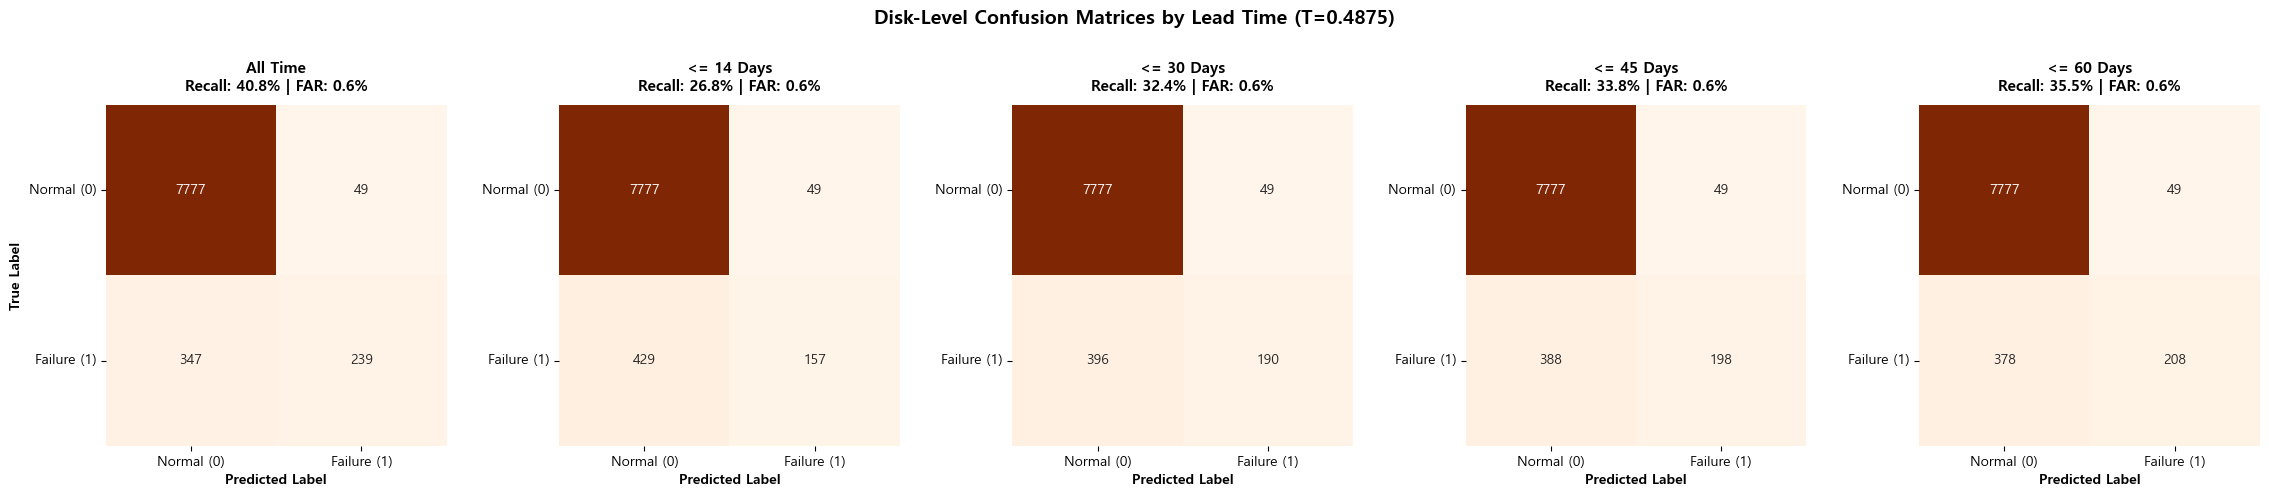

In [ ]:
horizons = [1000, 14, 30, 45, 60]  # 리드타임 구간
n_normal_disks = val_ent_res["n_normal_entities"]
n_failed_disks = val_ent_res["n_failure_entities"]
fp = val_ent_res["fa_count"]
tn = val_ent_res["n_normal_entities"] - fp

n_horizons = len(horizons)
fig, axes = plt.subplots(1, n_horizons, figsize=(4.6 * n_horizons, 4.5))
if n_horizons == 1:
    axes = [axes]
    
for i, horizon in enumerate(horizons):
    # 해당 리드타임 이하로 탐지된 TP 수 계산
    if horizon == 1000:
        tp_h = total_tp
        h_label = "All Time"
    else:
        tp_h = int(np.sum(lead_times <= horizon))
        h_label = f"<= {horizon} Days"
        
    fn_h = n_failed_disks - tp_h
    cm_disk = np.array([[tn, fp], [fn_h, tp_h]])
    
    sns.heatmap(cm_disk, annot=True, fmt="d", cmap="Oranges", cbar=False, square=True, ax=axes[i])
    axes[i].set_xticks([0.5, 1.5])
    axes[i].set_xticklabels(["Normal (0)", "Failure (1)"])
    axes[i].set_yticks([0.5, 1.5])
    axes[i].set_yticklabels(["Normal (0)", "Failure (1)"], rotation=0)
    axes[i].set_xlabel("Predicted Label", fontweight="bold")
    if i == 0:
        axes[i].set_ylabel("True Label", fontweight="bold")
        
    recall_pct = (tp_h / n_failed_disks * 100) if n_failed_disks > 0 else 0.0
    far_pct = (fp / n_normal_disks * 100) if n_normal_disks > 0 else 0.0
    axes[i].set_title(f"{h_label}\nRecall: {recall_pct:.1f}% | FAR: {far_pct:.1f}%", fontsize=11, fontweight="bold", pad=10)

plt.suptitle(f"Disk-Level Confusion Matrices by Lead Time (T={BEST_T:.4f})", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

👉 서브셋별 디스크 단위 PR-AUC 계산 중...
  ... 500/1,000 (50.0%) - 0.4s
  ... 1,000/1,000 (100.0%) - 0.8s
  - Subset 01 Disk Rolling PR-AUC: 0.28461
  ... 500/1,000 (50.0%) - 0.5s
  ... 1,000/1,000 (100.0%) - 0.8s
  - Subset 02 Disk Rolling PR-AUC: 0.29201
  ... 500/1,000 (50.0%) - 0.4s
  ... 1,000/1,000 (100.0%) - 0.8s
  - Subset 03 Disk Rolling PR-AUC: 0.31550
  ... 500/1,000 (50.0%) - 0.4s
  ... 1,000/1,000 (100.0%) - 0.8s
  - Subset 04 Disk Rolling PR-AUC: 0.30490
  ... 500/1,000 (50.0%) - 0.4s
  ... 1,000/1,000 (100.0%) - 0.8s
  - Subset 05 Disk Rolling PR-AUC: 0.30173
👉 Plot saved to: c:\Workspace\06_ML_projdect\26_1_COIN\results\06e_\plots\06e_subset_ensemble_effect.png


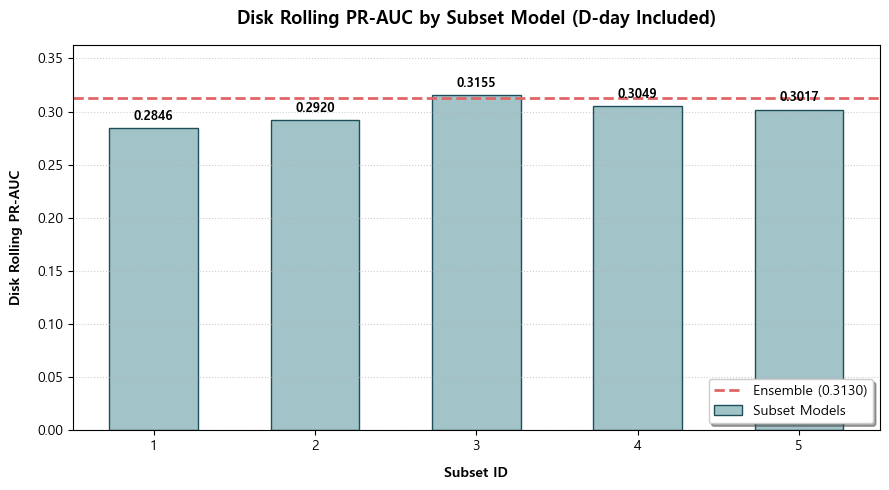

In [ ]:
# ── 서브셋별 성능 및 앙상블 효과 시각화 ───────────────────
print("👉 서브셋별 디스크 단위 PR-AUC 계산 중...")
subset_praucs = []
X_val = df_val[FEATURE_COLS].to_numpy(dtype=np.float32)

for idx, model in enumerate(ensemble.models):
    y_prob_sub = model.predict_proba(X_val)[:, 1]
    
    # 30일 Horizon 기준 Grid Search (Legacy API)
    s_data, s_fail, s_norm = prepare_disk_level_data(df_val, y_prob_sub)
    s_df = run_disk_level_grid_search(
        s_data, thresholds_grid, [1], s_fail, s_norm,
        log_dir=None, window_size=0, horizon=30
    )
    s_df_sorted = s_df.sort_values(by="recall").copy()
    s_df_sorted["precision"] = s_df_sorted["tps"] / (s_df_sorted["tps"] + s_df_sorted["fps"] + 1e-8)
    s_df_sorted["precision"] = s_df_sorted["precision"].fillna(1.0)
    sub_prauc = float(auc(s_df_sorted["recall"].values, s_df_sorted["precision"].values))
    
    print(f"  - Subset {idx+1:02d} Disk Rolling PR-AUC: {sub_prauc:.5f}")
    subset_praucs.append(sub_prauc)

# 시각화
plt.figure(figsize=(9, 5))
x_ticks = range(1, len(subset_praucs) + 1)
plt.bar(x_ticks, subset_praucs, color='#a2c4c9', edgecolor='#1f4e5b', width=0.55, label='Subset Models')

# 앙상블 성능 수평선 표시
plt.axhline(entity_prauc, color='#e06666', linestyle='--', linewidth=2, 
            label=f'Ensemble ({entity_prauc:.4f})')

# 텍스트 라벨 추가
for i, val in enumerate(subset_praucs):
    plt.text(i + 1, val + 0.005, f"{val:.4f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.title('Disk Rolling PR-AUC by Subset Model (D-day Included)', fontweight='bold', fontsize=13, pad=15)
plt.xlabel('Subset ID', fontweight='bold', labelpad=10)
plt.ylabel('Disk Rolling PR-AUC', fontweight='bold', labelpad=10)
plt.xticks(x_ticks)
plt.ylim(0, max(max(subset_praucs), entity_prauc) * 1.15)
plt.legend(loc='lower right', frameon=True, shadow=True)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()

# 이미지 저장
save_dir = ROOT / "results/06e_/plots"
save_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(save_dir / "06e_subset_ensemble_effect.png", dpi=300)
print(f"👉 Plot saved to: {save_dir / '06e_subset_ensemble_effect.png'}")
plt.show()